<a href="https://colab.research.google.com/github/sakthirameshchandar/House-Price-Prediction-/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [10]:
d = pd.read_csv("HPPM.csv")
print("First 5 rows of the dataset:")
print(d.head())

First 5 rows of the dataset:
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bathroom  balcony   price  
0  Coomee        1056       2.0      1.0   39.07  
1  Theanmp       2600       5.0      3.0  120.00  
2      NaN       1440       2.0      3.0   62.00  
3  Soiewre       1521       3.0      1.0   95.00  
4      NaN       1200       2.0      1.0   51.00  


In [7]:
print("\nDataset Info:")
print(d.info())

print("\nStatistical Summary:")
print(d.describe())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bathroom      13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
None

Statistical Summary:
           bathroom       balcony         price
count  13247.000000  12711.000000  13320.000000
mean       2.692610      1.584376    112.565627
std        1.341458      0.817263    148.971674
min        1.000000      0.000000      8.000000
25%        2.000000      1.000000     50.000000
50%        2.000000      2.000000  

In [8]:
print("\nMissing values:")
print(d.isnull().sum())


Missing values:
area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bathroom          73
balcony          609
price              0
dtype: int64


In [15]:
d['bathroom'] = d['bathroom'].fillna(d['bathroom'].mean())
d['balcony'] = d['balcony'].fillna(d['balcony'].mean())

d.dropna(subset=['price'], inplace=True)

In [16]:
def convert_sqft(value):
    try:
        if '-' in str(value):
            low, high = value.split('-')
            return (float(low) + float(high)) / 2
        return float(value)
    except:
        return np.nan


In [18]:
d['total_sqft'] = d['total_sqft'].apply(convert_sqft)
d['total_sqft'].fillna(d['total_sqft'].mean(), inplace=True)


d.drop_duplicates(inplace=True)

print("\nDataset shape after cleaning:", d.shape)



Dataset shape after cleaning: (12790, 9)


/tmp/ipython-input-3789323113.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['total_sqft'].fillna(d['total_sqft'].mean(), inplace=True)


In [25]:
label_encoder = LabelEncoder()
categorical_cols = ['area_type', 'availability', 'location', 'size', 'society']

for col in categorical_cols:
    d[col] = label_encoder.fit_transform(d[col].astype(str))




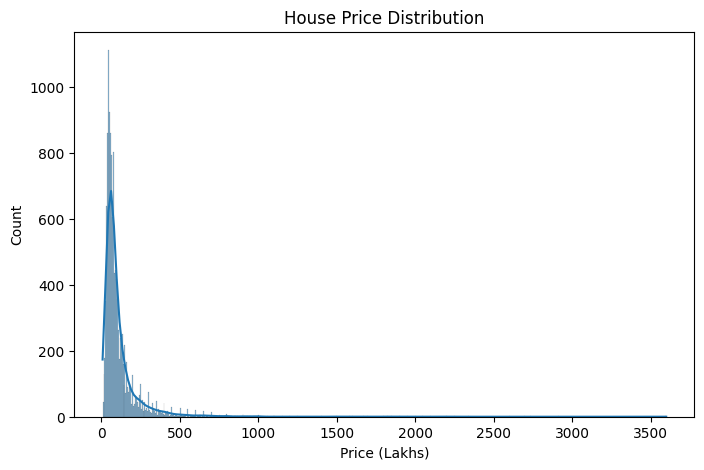

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(d['price'], kde=True)
plt.title("House Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.show()


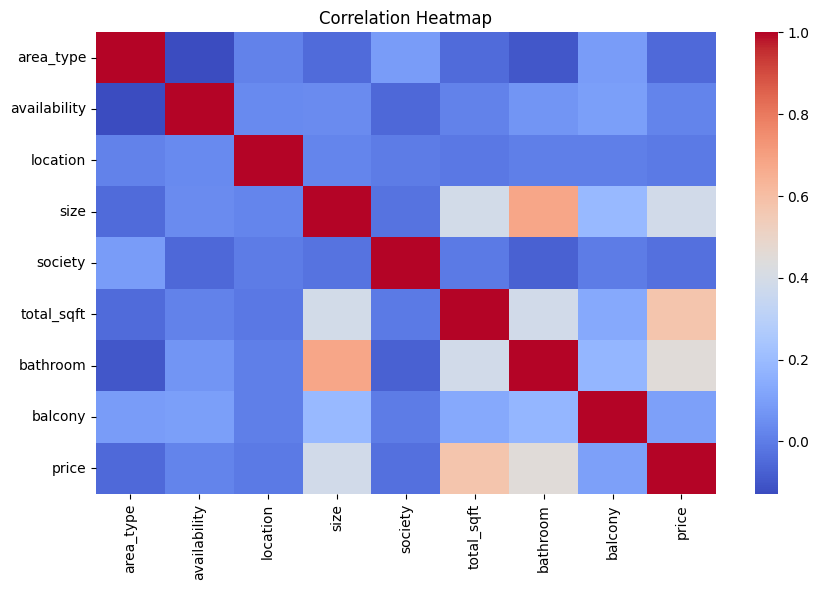

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(d.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [31]:
X = d.drop('price', axis=1)   # Input features
y = d['price']               # Target variable

print("\nSelected Features:")
print(X.columns)


Selected Features:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bathroom', 'balcony'],
      dtype='object')


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (10232, 8)
Testing size: (2558, 8)


In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully")


Linear Regression model trained successfully


In [35]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("Model Coefficients:")
print(coeff_df)

Model Coefficients:
        Feature  Coefficient
0     area_type    -0.571041
1  availability    -0.062935
2      location    -0.001828
3          size     1.209354
4       society    -0.002315
5    total_sqft     0.050011
6      bathroom    29.960889
7       balcony    -1.944879


In [36]:
y_pred = model.predict(X_test)

print("\nSample Predictions:")
print(y_pred[:5])


Sample Predictions:
[149.13916883  68.57663339  73.60553568  60.31866984 123.88949995]


In [37]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)



Model Performance:
MAE : 46.85272433972672
MSE : 12058.331224850626
RMSE: 109.81043313297069
R2  : 0.46082959147559266


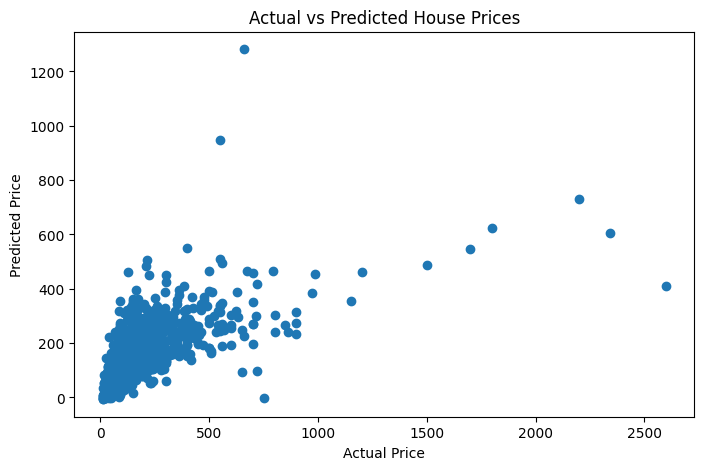

In [38]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


In [40]:
sample_house = X_test.iloc[0].values.reshape(1, -1)
predicted_price = model.predict(sample_house)

print("Predicted price for sample house:", predicted_price[0])


# =========================
# 16. CONCLUSION
# =========================

#print("\nConclusion:")
#print("This project uses Supervised Learning with Linear Regression.")
#print("The model predicts house prices based on given features.")
#print("Further improvement can be done using advanced ML models.")

Predicted price for sample house: 149.13916882947692


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [41]:
print("\nConclusion:")
print("This project uses Supervised Learning with Linear Regression.")
print("The model predicts house prices based on given features.")
print("Further improvement can be done using advanced ML models.")


Conclusion:
This project uses Supervised Learning with Linear Regression.
The model predicts house prices based on given features.
Further improvement can be done using advanced ML models.
